 ENVIRONMENT SETUP

In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [2]:
import os
import random
import warnings
from collections import Counter
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchmetrics
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import wandb
from segmentation_models_pytorch.losses import FocalLoss
 
warnings.filterwarnings("ignore")
print("done")

done


CONFIGURATION  — edit here, nowhere else

In [3]:
class CFG:
    SEED: int = 42
    MS_BANDS: int = 5  
    HS_BANDS: int = 124
 
    BASE_PATH: str = "/kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train"
    IMG_H:     int = 64
    IMG_W:     int = 64
 
    LABEL_MAPPING: dict = None   
 
    N_FOLDS:       int   = 5
    EPOCHS:        int   = 50
    BATCH_SIZE:    int   = 16
    LR:            float = 1e-4
    WEIGHT_DECAY:  float = 1e-4
    PATIENCE:      int   = 8     
    GRAD_CLIP:     float = 1.0   
 
    BACKBONE:      str   = "resnet50"
    NUM_CLASSES:   int   = 3    
 
    FOCAL_ALPHA:   float = 0.25
    FOCAL_GAMMA:   float = 2.0
 
    WANDB_PROJECT: str   = "icpr2026-agvision"
    WANDB_ENTITY:  str   = None   
 
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 2
 
 
def seed_everything(seed: int = CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
seed_everything()
print(f"Device: {CFG.DEVICE}")
 

Device: cuda


GOOGLE DRIVE MOUNT + DATA DISCOVERY

In [4]:
from pathlib import Path

base_path = Path(CFG.BASE_PATH)

hs_files = sorted(list(base_path.rglob('HS/*.tif')))
ms_files = sorted(list(base_path.rglob('MS/*.tif')))
rgb_files = sorted(list(base_path.rglob('RGB/*.png')))

print(f"HS files found: {len(hs_files)}")
print(f"MS files found: {len(ms_files)}")
print(f"RGB files found: {len(rgb_files)}")

if len(hs_files) > 0:
    print(f"First HS file: {hs_files[0]}")

HS files found: 600
MS files found: 600
RGB files found: 600
First HS file: /kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train/HS/Health_hyper_1.tif


DATA LOADING & SANITY CHECKS

In [5]:
import tifffile as tiff  
 
sample_hs  = tiff.imread(str(hs_files[0]))
sample_ms  = tiff.imread(str(ms_files[0]))
sample_rgb = np.array(Image.open(str(rgb_files[0])))
 
print(f"\nSingle sample shapes:")
print(f"  HS  : {sample_hs.shape}  dtype={sample_hs.dtype}")
print(f"  MS  : {sample_ms.shape}  dtype={sample_ms.dtype}")
print(f"  RGB : {sample_rgb.shape}  dtype={sample_rgb.dtype}")
 
CFG.HS_BANDS = sample_hs.shape[-1] if sample_hs.ndim == 3 else sample_hs.shape[0]
print(f"\nActual HS bands: {CFG.HS_BANDS}")
 
labels_raw = []
for f in hs_files:
    stem = f.stem   
    label_str = stem.split("_")[0]
    labels_raw.append(label_str)
 
class_counts = Counter(labels_raw)
print(f"\nClass distribution: {dict(class_counts)}")
 
CFG.LABEL_MAPPING = {cls: i for i, cls in enumerate(sorted(class_counts.keys()))}
CFG.NUM_CLASSES   = len(CFG.LABEL_MAPPING)
print(f"Label mapping : {CFG.LABEL_MAPPING}")


Single sample shapes:
  HS  : (32, 32, 125)  dtype=uint16
  MS  : (64, 64, 5)  dtype=uint16
  RGB : (64, 64, 3)  dtype=uint8

Actual HS bands: 125

Class distribution: {'Health': 200, 'Other': 200, 'Rust': 200}
Label mapping : {'Health': 0, 'Other': 1, 'Rust': 2}


PREPROCESSING UTILITIES

In [6]:
def normalize_array(arr: np.ndarray) -> np.ndarray:
    """Per-band z-score normalisation."""
def normalize_array(arr: np.ndarray) -> np.ndarray:
    """Per-band z-score normalisation."""
    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    out = np.zeros_like(arr, dtype=np.float32)
    for b in range(arr.shape[-1]):
        band = arr[..., b].astype(np.float32)
        mean, std = band.mean(), band.std()
        out[..., b] = (band - mean) / (std + 1e-8)
    return out
 
def preprocess_sample(idx: int):
    """
    Load, resize, and normalise one multimodal sample.
    Returns (hs_norm, ms_norm, rgb_norm, label_int).
    """
    H, W = CFG.IMG_H, CFG.IMG_W
 
    hs  = tiff.imread(str(hs_files[idx])).astype(np.float32)
    ms  = tiff.imread(str(ms_files[idx])).astype(np.float32)
    rgb = np.array(Image.open(str(rgb_files[idx]))).astype(np.float32)
 
    if hs.ndim == 2:   hs  = hs[..., np.newaxis]
    if ms.ndim == 2:   ms  = ms[..., np.newaxis]
    if rgb.ndim == 2:  rgb = rgb[..., np.newaxis]
 
    from skimage.transform import resize as sk_resize
    hs  = sk_resize(hs,  (H, W, hs.shape[-1]),  preserve_range=True, anti_aliasing=True)
    ms  = sk_resize(ms,  (H, W, ms.shape[-1]),  preserve_range=True, anti_aliasing=True)
    rgb = sk_resize(rgb, (H, W, rgb.shape[-1]), preserve_range=True, anti_aliasing=True)
 
    hs_norm  = normalize_array(hs)
    ms_norm  = normalize_array(ms)
    rgb_norm = (rgb / 255.0).astype(np.float32)   # simple [0,1] for RGB
 
    label_str = hs_files[idx].stem.split("_")[0]
    label     = CFG.LABEL_MAPPING[label_str]
 
    return hs_norm, ms_norm, rgb_norm, label
 
 
hs_s, ms_s, rgb_s, lbl_s = preprocess_sample(0)
print(f"\nSample 0 → HS {hs_s.shape}, MS {ms_s.shape}, RGB {rgb_s.shape}, label {lbl_s}")


Sample 0 → HS (64, 64, 125), MS (64, 64, 5), RGB (64, 64, 3), label 0


 EXPLORATORY DATA ANALYSIS

Skipped image 114 - unexpected band count: 32
Skipped image 25 - unexpected band count: 32
Skipped image 281 - unexpected band count: 32
Skipped image 250 - unexpected band count: 32
Skipped image 228 - unexpected band count: 32
Skipped image 142 - unexpected band count: 32
Skipped image 104 - unexpected band count: 32
Skipped image 558 - unexpected band count: 32
Skipped image 89 - unexpected band count: 32
Skipped image 432 - unexpected band count: 32
Skipped image 32 - unexpected band count: 32
Skipped image 30 - unexpected band count: 32
Skipped image 95 - unexpected band count: 32
Skipped image 223 - unexpected band count: 32
Skipped image 238 - unexpected band count: 32
Skipped image 517 - unexpected band count: 32
Skipped image 27 - unexpected band count: 32
Skipped image 574 - unexpected band count: 32
Skipped image 203 - unexpected band count: 32
Skipped image 429 - unexpected band count: 32
Skipped image 225 - unexpected band count: 32
Skipped image 459 - unexpected band coun

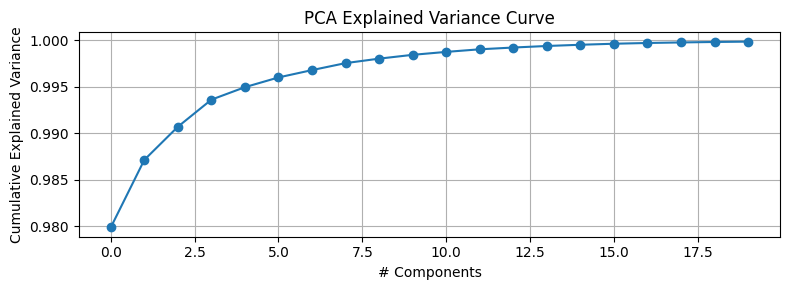

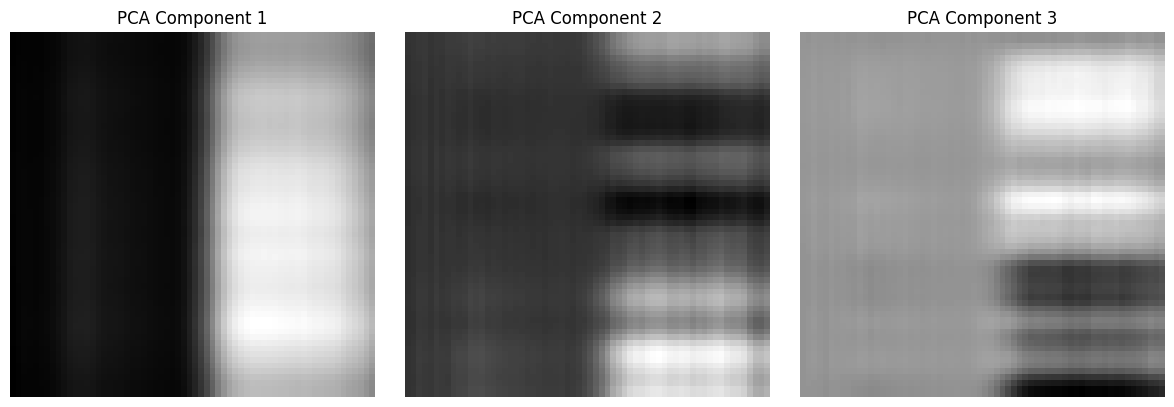

In [7]:
def plot_mean_spectral_signature(n_samples: int = 50):
    indices = random.sample(range(len(hs_files)), min(n_samples, len(hs_files)))
    band_means = []
    
    for i in indices:
        img = tiff.imread(str(hs_files[i])).astype(np.float32)
        
        if img.ndim == 3 and img.shape[0] < img.shape[-1]:
            img = np.moveaxis(img, 0, -1) 
            
        img_mean = img.mean(axis=(0, 1))
        
        if img_mean.shape[0] == 12: 
            band_means.append(img_mean)
        else:
            print(f"Skipped image {i} - unexpected band count: {img_mean.shape[0]}")
            
    if len(band_means) == 0:
        print("Error: No valid images to plot.")
        return
        
    mean_sig = np.mean(band_means, axis=0)
    
    plt.figure(figsize=(12, 4))
    plt.plot(mean_sig)
    plt.title('Mean Spectral Signature Across HS Bands')
    plt.xlabel('Band Index')
    plt.ylabel('Mean Intensity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_mean_spectral_signature()


def run_pca_analysis(n_components: int = 10, n_samples: int = 100):
    """
    Flatten HS patches → PCA.  Shows cumulative explained variance
    and the first 3 PCA component images.
    """
    indices = random.sample(range(len(hs_files)), min(n_samples, len(hs_files)))
    hs_list = []
    
    for i in indices:
        arr = tiff.imread(str(hs_files[i])).astype(np.float32)
        
        if arr.ndim == 3 and arr.shape[0] < arr.shape[-1]:
            arr = np.moveaxis(arr, 0, -1)
            
        if arr.ndim == 2:
            arr = arr[..., np.newaxis]
            
        from skimage.transform import resize as sk_resize
        arr = sk_resize(arr, (CFG.IMG_H, CFG.IMG_W, arr.shape[-1]),
                        preserve_range=True, anti_aliasing=True)
        hs_list.append(arr)

    hs_stack  = np.stack(hs_list, axis=0)          # (N, H, W, C)
    N, H, W, C = hs_stack.shape
    hs_flat   = hs_stack.reshape(N * H * W, C)

    pca = PCA(n_components=min(n_components, C))
    pca.fit(hs_flat)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(8, 3))
    plt.plot(cumvar, marker='o')
    plt.title("PCA Explained Variance Curve")
    plt.xlabel("# Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    hs0_flat = hs_stack[0].reshape(H * W, C)
    pca_img  = pca.transform(hs0_flat).reshape(H, W, -1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    plot_components = min(3, pca_img.shape[-1])
    for k in range(plot_components):
        axes[k].imshow(pca_img[..., k], cmap='gray')
        axes[k].set_title(f"PCA Component {k+1}")
        axes[k].axis("off")
        
    plt.tight_layout()
    plt.show()

    return pca

pca_model = run_pca_analysis(n_components=20, n_samples=50)

AUGMENTATION STRATEGY

In [8]:
def get_augmentation(is_train: bool, img_h: int = CFG.IMG_H, img_w: int = CFG.IMG_W):
    if is_train:
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
        ], additional_targets={'hs': 'image', 'ms': 'image'}) 
    else:
        return A.Compose([], additional_targets={'hs': 'image', 'ms': 'image'})
print("done")

done


MULTIMODAL DATASET

In [9]:
def convert_to_tensors(hs, ms, rgb, label, target_hs_bands: int = CFG.HS_BANDS):
    hs_t  = torch.tensor(hs,  dtype=torch.float32).permute(2, 0, 1)
    ms_t  = torch.tensor(ms,  dtype=torch.float32).permute(2, 0, 1)
    rgb_t = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)
    lbl_t = torch.tensor(label, dtype=torch.long)
    
    current_bands = hs_t.shape[0]
    if current_bands > target_hs_bands:
        hs_t = hs_t[:target_hs_bands, :, :]
    elif current_bands < target_hs_bands:
        padding = torch.zeros((target_hs_bands - current_bands, hs_t.shape[1], hs_t.shape[2]))
        hs_t = torch.cat([hs_t, padding], dim=0)

    return hs_t, ms_t, rgb_t, lbl_t
 
 
class MultimodalDataset(Dataset):
    def __init__(self, hs_files, ms_files, rgb_files, is_train: bool = True):
        self.hs_files  = hs_files
        self.ms_files  = ms_files
        self.rgb_files = rgb_files
        self.aug       = get_augmentation(is_train)
 
    def __len__(self):
        return len(self.hs_files)
 
    def __getitem__(self, idx):
        hs, ms, rgb, label = preprocess_sample(idx)
 
        if self.aug:
            augmented = self.aug(image=rgb, hs=hs, ms=ms)
            rgb = augmented['image']
            hs = augmented['hs']
            ms = augmented['ms']
 
        hs_t, ms_t, rgb_t, lbl_t = convert_to_tensors(hs, ms, rgb, label)
        return {"hs": hs_t, "ms": ms_t, "rgb": rgb_t, "label": lbl_t}
print("done")

done


MODEL ZOO

In [10]:
class SEBlock(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )
 
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s
 
 
class ResNet50Baseline(nn.Module):
    """
    Standard ResNet-50 with first conv replaced to accept `num_bands` channels.
    Uses only hyperspectral input (no fusion).
    """
    def __init__(self, num_bands: int = CFG.HS_BANDS, num_classes: int = CFG.NUM_CLASSES):
        super().__init__()
        self.model = timm.create_model(
            "resnet50", pretrained=True,
            in_chans=num_bands,
            num_classes=num_classes,
        )
 
    def forward(self, batch):
        return self.model(batch["hs"])
 
 
class EfficientNetBaseline(nn.Module):
    """
    EfficientNet-B2 receiving concatenated MS + RGB (ms_bands + 3 channels).
    """
    def __init__(self, ms_bands: int = CFG.MS_BANDS, num_classes: int = CFG.NUM_CLASSES):
        super().__init__()
        in_chans = ms_bands + 3
        self.model = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=in_chans,
            num_classes=num_classes,
        )
 
    def forward(self, batch):
        x = torch.cat([batch["ms"], batch["rgb"]], dim=1)
        return self.model(x)
 
 
class SEFusionModel(nn.Module):
    """
    Novel contribution:
      - Branch A: ConvNeXt-Small backbone on HS (full spectral input)
      - Branch B: EfficientNet-B2 backbone on MS+RGB
      - SE-weighted feature fusion before classification head
    This is your 'go-beyond-baseline' model.
    """
    def __init__(
        self,
        hs_bands:    int = CFG.HS_BANDS,
        ms_bands:    int = CFG.MS_BANDS,
        num_classes: int = CFG.NUM_CLASSES,
        embed_dim:   int = 512,
    ):
        super().__init__()
 
        self.hs_backbone = timm.create_model(
            "convnext_small", pretrained=True,
            in_chans=hs_bands, num_classes=0,   
            global_pool="avg",
        )
        hs_feat_dim = self.hs_backbone.num_features
 
        self.ms_backbone = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=ms_bands + 3, num_classes=0,
            global_pool="avg",
        )
        ms_feat_dim = self.ms_backbone.num_features
 
        self.hs_proj = nn.Sequential(
            nn.Linear(hs_feat_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )
        self.ms_proj = nn.Sequential(
            nn.Linear(ms_feat_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )
 
        self.se = SEBlock(2 * embed_dim, reduction=16)
 
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(2 * embed_dim, 256),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, batch):
        hs_feat = self.hs_backbone(batch["hs"])         
        ms_feat = self.ms_backbone(
            torch.cat([batch["ms"], batch["rgb"]], dim=1)
        )                                                
 
        hs_emb = self.hs_proj(hs_feat)                  
        ms_emb = self.ms_proj(ms_feat)                 
 
        fused = torch.cat([hs_emb, ms_emb], dim=1)      
 
        fused_4d = fused.unsqueeze(-1).unsqueeze(-1)    # (B, 2E, 1, 1)
        fused_se = self.se(fused_4d).squeeze(-1).squeeze(-1)
 
        logits = self.classifier(fused_se)
        return logits
class NoSEFusionModel(nn.Module):
    
    
    def __init__(
        self,
        hs_bands:    int = CFG.HS_BANDS,
        ms_bands:    int = CFG.MS_BANDS,
        num_classes: int = CFG.NUM_CLASSES,
        embed_dim:   int = 512,
    ):
        super().__init__()
        
        self.hs_backbone = timm.create_model(
            "convnext_small", pretrained=True,
            in_chans=hs_bands, num_classes=0, global_pool="avg",
        )
        hs_feat_dim = self.hs_backbone.num_features
 
        self.ms_backbone = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=ms_bands + 3, num_classes=0, global_pool="avg",
        )
        ms_feat_dim = self.ms_backbone.num_features
 
        self.hs_proj = nn.Sequential(
            nn.Linear(hs_feat_dim, embed_dim), nn.GELU(), nn.LayerNorm(embed_dim),
        )
        self.ms_proj = nn.Sequential(
            nn.Linear(ms_feat_dim, embed_dim), nn.GELU(), nn.LayerNorm(embed_dim),
        )
 
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(2 * embed_dim, 256),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, batch):
        hs_feat = self.hs_backbone(batch["hs"])         
        ms_feat = self.ms_backbone(
            torch.cat([batch["ms"], batch["rgb"]], dim=1)
        )                                                
 
        hs_emb = self.hs_proj(hs_feat)                  
        ms_emb = self.ms_proj(ms_feat)                  
 
        fused = torch.cat([hs_emb, ms_emb], dim=1)      
 
        logits = self.classifier(fused)
        return logits
 
def build_model(name: str = "proposed") -> nn.Module:
    if name == "resnet50":
        return ResNet50Baseline()
    elif name == "efficientnet":
        return EfficientNetBaseline()
    elif name == "proposed" or name == "no_focal_loss":
        return SEFusionModel()
    elif name == "no_se":
        return NoSEFusionModel()
    else:
        raise ValueError(f"Unknown model: {name}")
print("done")

done


 LOSS FUNCTION

In [11]:
criterion = FocalLoss(
    mode="multiclass",
    alpha=CFG.FOCAL_ALPHA,
    gamma=CFG.FOCAL_GAMMA,
)
print("Focal Loss criterion: ready")


Focal Loss criterion: ready


OPTIMISER + LR SCHEDULER

In [12]:
def build_optimizer(model: nn.Module):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if "classifier" in name or "proj" in name or "se" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR / 10},
        {"params": head_params,     "lr": CFG.LR},
    ], weight_decay=CFG.WEIGHT_DECAY)
    return optimizer


def build_scheduler(optimizer, steps_per_epoch: int):
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[CFG.LR / 10, CFG.LR],
        steps_per_epoch=steps_per_epoch,
        epochs=CFG.EPOCHS,
        pct_start=0.1,
    )
print("done")

done


WEIGHTS & BIASES INITIALISATION

In [13]:
def init_wandb(fold: int, model_name: str):
    wandb.init(
        project=CFG.WANDB_PROJECT,
        entity=CFG.WANDB_ENTITY,
        name=f"{model_name}_fold{fold}",
        config={
            "backbone":    CFG.BACKBONE,
            "epochs":      CFG.EPOCHS,
            "batch_size":  CFG.BATCH_SIZE,
            "lr":          CFG.LR,
            "n_folds":     CFG.N_FOLDS,
            "hs_bands":    CFG.HS_BANDS,
            "num_classes": CFG.NUM_CLASSES,
            "focal_gamma": CFG.FOCAL_GAMMA,
        },
        reinit=True,
    )
print("done")

done


TRAINING LOOP

In [14]:
def run_cross_validation(model_name: str = "proposed", use_wandb: bool = True):
    all_indices  = np.arange(len(hs_files))
    all_labels   = np.array([
        CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_files
    ])

    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)

    fold_results = []
    all_models   = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels)):
        model, history, preds, labels, probs = run_fold(
            fold, train_idx, val_idx,
            model_name=model_name,
            use_wandb=use_wandb,
        )
        fold_results.append({"fold": fold, "preds": preds,
                              "labels": labels, "probs": probs,
                              "history": history})
        all_models.append(model)

    print(f"\n{'='*60}")
    print(f"  CROSS-VALIDATION SUMMARY  ({model_name})")
    print(f"{'='*60}")
    for r in fold_results:
        acc = (r["preds"] == r["labels"]).mean()
        print(f"  Fold {r['fold']+1}: acc={acc:.4f}")

    return fold_results, all_models
print("done")

done


5-FOLD STRATIFIED CROSS-VALIDATION

In [15]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
        labels = batch["label"]

        optimizer.zero_grad()
        logits = model(batch)
        loss   = criterion(logits, labels) 
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        batch  = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
        labels = batch["label"]
        logits = model(batch)
        loss   = criterion(logits, labels)

        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def run_fold(
    fold:       int,
    train_idx:  np.ndarray,
    val_idx:    np.ndarray,
    model_name: str = "proposed",
    use_wandb:  bool = True,
):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1} / {CFG.N_FOLDS}  |  model={model_name}")
    print(f"{'='*60}")

    hs_train  = [hs_files[i]  for i in train_idx]
    ms_train  = [ms_files[i]  for i in train_idx]
    rgb_train = [rgb_files[i] for i in train_idx]
    hs_val    = [hs_files[i]  for i in val_idx]
    ms_val    = [ms_files[i]  for i in val_idx]
    rgb_val   = [rgb_files[i] for i in val_idx]

    train_ds = MultimodalDataset(hs_train, ms_train, rgb_train, is_train=True)
    val_ds   = MultimodalDataset(hs_val,   ms_val,   rgb_val,   is_train=False)

    train_labels = [CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_train]
    class_weights = {c: 1.0 / cnt for c, cnt in Counter(train_labels).items()}
    sample_weights = [class_weights[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                              sampler=sampler, num_workers=CFG.NUM_WORKERS,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                              shuffle=False, num_workers=CFG.NUM_WORKERS,
                              pin_memory=True)

    model     = build_model(model_name).to(CFG.DEVICE)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, len(train_loader))

    if model_name == "no_focal_loss":
        fold_criterion = nn.CrossEntropyLoss()
    else:
        fold_criterion = FocalLoss(
            mode="multiclass",
            alpha=CFG.FOCAL_ALPHA,
            gamma=CFG.FOCAL_GAMMA,
        )

    if use_wandb:
        init_wandb(fold, model_name)

    best_val_loss  = float("inf")
    patience_count = 0
    best_model_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(CFG.EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, fold_criterion)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, fold_criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if use_wandb:
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc":  train_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "lr_backbone": optimizer.param_groups[0]["lr"],
                "lr_head":     optimizer.param_groups[1]["lr"],
            })

        print(f"  Ep {epoch+1:3d}/{CFG.EPOCHS} | "
              f"TL={train_loss:.4f} TA={train_acc:.4f} | "
              f"VL={val_loss:.4f} VA={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_count   = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= CFG.PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    
    _, val_acc, preds, labels, probs = evaluate(model, val_loader, fold_criterion)

    print(f"\n  Fold {fold+1} best val_acc = {val_acc:.4f}")
    print(classification_report(labels, preds,
                                 labels=list(CFG.LABEL_MAPPING.values()), # <-- Add this line!
                                 target_names=list(CFG.LABEL_MAPPING.keys())))

    if use_wandb:
        wandb.finish()

    return model, history, preds, labels, probs
print("done")

done


EVALUATION UTILITIES

In [16]:
def full_evaluation(preds, labels, probs, class_names=None):
    """Per-class metrics, confusion matrix, ROC-AUC."""
    if class_names is None:
        class_names = list(CFG.LABEL_MAPPING.keys())

    print("\n── Classification Report ──")
    print(classification_report(labels, preds, target_names=class_names))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    n_classes = CFG.NUM_CLASSES
    lb = label_binarize(labels, classes=list(range(n_classes)))
    if n_classes == 2:
        auc = roc_auc_score(lb, probs[:, 1])
        print(f"ROC-AUC (binary): {auc:.4f}")
    else:
        auc = roc_auc_score(lb, probs, multi_class="ovr", average="macro")
        print(f"ROC-AUC (macro OvR): {auc:.4f}")


def plot_training_curves(history: dict, fold: int = 0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title(f"Fold {fold+1} — Loss")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history["val_acc"], label="Val Acc", color="green")
    axes[1].set_title(f"Fold {fold+1} — Val Accuracy")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()
print("done")

done


ABLATION STUDY HELPER

In [17]:
def run_ablation():
    
    all_indices = np.arange(len(hs_files))
    all_labels  = np.array([
        CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_files
    ])
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    train_idx, val_idx = next(iter(skf.split(all_indices, all_labels)))

    results = {}
    
    variants = ["proposed", "no_se", "no_focal_loss"]
    
    for name in variants:
        print(f"\n[ABLATION] Variant: {name}")
        _, history, preds, labels, _ = run_fold(
            fold=0, train_idx=train_idx, val_idx=val_idx,
            model_name=name, use_wandb=False,
        )
        acc = (preds == labels).mean()
        results[name] = acc
        print(f"  → val_acc = {acc:.4f}")

    print("\n── Ablation Summary ──")
    for name, acc in results.items():
        print(f"  {name:20s}: {acc:.4f}")
    return results
print("done")

done


INFERENCE / SUBMISSION

In [ ]:
def ensemble_predict(models, test_hs, test_ms, test_rgb):
    
    test_ds     = MultimodalDataset(test_hs, test_ms, test_rgb, is_train=False)
    test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE,
                             shuffle=False, num_workers=CFG.NUM_WORKERS)
 
    all_probs = []
    for model in models:
        model.eval()
        fold_probs = []
        with torch.no_grad():
            for batch in test_loader:
                batch = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
                logits = model(batch)
                probs  = F.softmax(logits, dim=1).cpu().numpy()
                fold_probs.append(probs)
        all_probs.append(np.vstack(fold_probs))
 
    avg_probs = np.mean(all_probs, axis=0)   # (N, num_classes)
    preds     = avg_probs.argmax(axis=1)
 
    inv_map   = {v: k for k, v in CFG.LABEL_MAPPING.items()}
    pred_labels = [inv_map[p] for p in preds]
    return pred_labels, avg_probs
 
 
def generate_submission(models, test_path: str, out_csv: str = "submission.csv"):
    import pandas as pd
    test_base = Path(test_path)
    t_hs  = sorted((test_base / "hs").glob("*.tiff"))
    t_ms  = sorted((test_base / "ms").glob("*.tiff"))
    t_rgb = sorted((test_base / "rgb").glob("*.png"))
 
    pred_labels, _ = ensemble_predict(models, t_hs, t_ms, t_rgb)
    df = pd.DataFrame({"filename": [f.name for f in t_hs], "label": pred_labels})
    df.to_csv(out_csv, index=False)
    print(f"Submission saved to {out_csv}")
    return df
 
 


if __name__ == "__main__":
 
 
    fold_results, trained_models = run_cross_validation(
        model_name="proposed",
        use_wandb=True,   
    )
 
    best_fold = max(fold_results, key=lambda r: (r["preds"] == r["labels"]).mean())
    plot_training_curves(best_fold["history"], fold=best_fold["fold"])
    full_evaluation(best_fold["preds"], best_fold["labels"], best_fold["probs"])
 


  FOLD 1 / 5  |  model=proposed


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  Ep   1/50 | TL=0.3187 TA=0.3187 | VL=0.2722 VA=0.3000
  Ep   2/50 | TL=0.2268 TA=0.4437 | VL=0.1699 VA=0.6167
  Ep   3/50 | TL=0.1768 TA=0.5250 | VL=0.1544 VA=0.6667
  Ep   4/50 | TL=0.1645 TA=0.5958 | VL=0.1044 VA=0.9917
  Ep   5/50 | TL=0.1489 TA=0.6646 | VL=0.1368 VA=0.8417
  Ep   6/50 | TL=0.1605 TA=0.5792 | VL=0.2001 VA=0.4250
  Ep   7/50 | TL=0.1492 TA=0.6542 | VL=0.1289 VA=0.8917
  Ep   8/50 | TL=0.1509 TA=0.6562 | VL=0.1444 VA=0.8250
  Ep   9/50 | TL=0.1351 TA=0.6854 | VL=0.0997 VA=0.8917
  Ep  10/50 | TL=0.1356 TA=0.6750 | VL=0.0952 VA=0.9417
  Ep  11/50 | TL=0.1415 TA=0.6354 | VL=0.1146 VA=0.8833
  Ep  12/50 | TL=0.1280 TA=0.6875 | VL=0.1762 VA=0.7250
  Ep  13/50 | TL=0.1260 TA=0.7354 | VL=0.0790 VA=0.9250
  Ep  14/50 | TL=0.1085 TA=0.7625 | VL=0.0878 VA=0.9333
  Ep  15/50 | TL=0.1192 TA=0.7271 | VL=0.1266 VA=0.7083
  Ep  16/50 | TL=0.1087 TA=0.7875 | VL=0.0750 VA=0.8667
  Ep  17/50 | TL=0.0972 TA=0.8000 | VL=0.0652 VA=0.9250
  Ep  18/50 | TL=0.0988 TA=0.7792 | VL=0.0623 VA